# Semana 14 - Aplicacion de los Conceptos de GANs en Google Colab


En esta actividad se implementa una **Red Generativa Adversarial (GAN)** desde cero utilizando el dataset **MNIST** en Google Colab.  
El objetivo es comprender la dinamica adversarial entre el **Generador** y el **Discriminador**, y analizar los resultados del proceso de entrenamiento.

| Componente | Descripcion |
|---|---|
| **Dataset** | MNIST - digitos escritos a mano (28x28, escala de grises) |
| **Generador** | Red densa que transforma ruido aleatorio en imagenes sinteticas |
| **Discriminador** | Red densa que clasifica imagenes como reales o falsas |
| **Entrenamiento** | Adversarial: G intenta enganar a D; D intenta no ser enganado |
| **Evaluacion** | Loss de G y D por epoca, imagenes generadas en intervalos |

---

## 1. Importaciones y Configuracion

In [ ]:
import numpy as np                          # Operaciones numericas y generacion de ruido
import matplotlib.pyplot as plt             # Visualizacion de imagenes y curvas de perdida
import tensorflow as tf                     # Framework principal de Deep Learning
from tensorflow import keras               # API de alto nivel para construir modelos
from tensorflow.keras import layers        # Capas individuales (Dense, LeakyReLU, etc.)
import warnings
warnings.filterwarnings('ignore')

# Semillas de aleatoriedad: garantizan que los resultados sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('Configuracion lista')

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Configuracion lista


## 2. Carga y Preprocesamiento del Dataset

**MNIST** contiene 70 000 imagenes de digitos manuscritos (0-9) de 28x28 pixeles.  
Para el entrenamiento de la GAN solo necesitamos las imagenes (sin etiquetas): el discriminador aprende a distinguir imagenes reales de imagenes sinteticas producidas por el generador.

In [ ]:
# Cargar MNIST directamente desde Keras
# mnist.load_data() retorna dos tuplas: (train_images, train_labels), (test_images, test_labels)
# Para GANs usaremos todas las imagenes juntas (train + test) para maximizar datos reales
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Combinar train y test para tener mas imagenes reales disponibles
x_all = np.concatenate([x_train, x_test], axis=0)  # shape: (70000, 28, 28)

# Normalizacion al rango [-1, 1]:
# Las GANs se benefician de este rango porque la activacion 'tanh' del generador
# tambien produce valores en [-1, 1], haciendo coherente la distribucion de salida
x_all = (x_all.astype('float32') / 127.5) - 1.0    # [0,255] -> [-1, 1]

# Aplanar cada imagen de 28x28 a un vector de 784 dimensiones
# La arquitectura densa (fully connected) requiere vectores 1D, no matrices 2D
x_all = x_all.reshape(-1, 784)                      # shape final: (70000, 784)

print(f'Forma del dataset combinado: {x_all.shape}')
print(f'Rango de valores: [{x_all.min():.2f}, {x_all.max():.2f}]')
print(f'Total de imagenes reales disponibles: {x_all.shape[0]:,}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma del dataset combinado: (70000, 784)
Rango de valores: [-1.00, 1.00]
Total de imagenes reales disponibles: 70,000


## 3. Arquitectura del Generador

El **Generador** recibe un **vector de ruido aleatorio** (espacio latente de 100 dimensiones)  
y lo transforma progresivamente en una imagen sintetica de 784 pixeles.

**Diseno de la arquitectura:**
- Capas densas que expanden el ruido de 100 -> 256 -> 512 -> 784 neuronas
- `LeakyReLU` como activacion interna: permite gradientes pequenos incluso para valores negativos, evitando el problema del 'dying ReLU'
- `tanh` en la capa de salida: produce valores en [-1, 1], coherente con la normalizacion del dataset

In [ ]:
LATENT_DIM = 100   # Dimensionalidad del espacio latente (vector de ruido de entrada)

def build_generator():
    model = keras.Sequential(name='Generador')

    # Capa 1: expande el vector de ruido (100) a 256 neuronas
    model.add(layers.Dense(256, input_dim=LATENT_DIM))
    # LeakyReLU: como ReLU pero permite un pequeno gradiente negativo (alpha=0.2)
    # Esto estabiliza el entrenamiento y evita neuronas 'muertas' en el generador
    model.add(layers.LeakyReLU(alpha=0.2))

    # Capa 2: expande de 256 a 512 neuronas para capturar mas patrones
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))

    # Capa de salida: 784 neuronas = 28x28 pixeles de la imagen generada
    # tanh produce valores en [-1, 1], igual que la normalizacion del dataset real
    model.add(layers.Dense(784, activation='tanh'))

    return model

generator = build_generator()
generator.summary()

Model: "Generador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Arquitectura del Discriminador

El **Discriminador** recibe una imagen de 784 pixeles (real o falsa)  
y predice si es **real (1)** o **generada (0)**.

**Diseno de la arquitectura:**
- Capas densas que comprimen 784 -> 512 -> 256 -> 1 neurona
- `LeakyReLU` para las capas internas por las mismas razones que en el generador
- `Dropout` para regularizacion: evita que el discriminador memorice el dataset y se vuelva demasiado fuerte, lo que bloquearia el aprendizaje del generador
- `sigmoid` en la salida: produce una probabilidad entre 0 y 1

In [ ]:
def build_discriminator():
    model = keras.Sequential(name='Discriminador')

    # Capa 1: recibe la imagen de 784 pixeles y la reduce a 512 neuronas
    model.add(layers.Dense(512, input_dim=784))
    model.add(layers.LeakyReLU(alpha=0.2))
    # Dropout(0.3): durante el entrenamiento, desactiva aleatoriamente el 30% de las neuronas
    # Evita que el discriminador se sobreajuste y aplaste al generador demasiado rapido
    model.add(layers.Dropout(0.3))

    # Capa 2: reduce de 512 a 256 neuronas para mayor abstraccion
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Capa de salida: 1 neurona con sigmoid -> probabilidad de que la imagen sea real
    # sigmoid(x) en (0, 1): valores cercanos a 1 = 'real', cercanos a 0 = 'falsa'
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compilacion de los Modelos

La compilacion de una GAN sigue una logica especial:
1. El **discriminador** se compila y entrena de forma independiente con imagenes reales y falsas
2. El **modelo GAN combinado** congela los pesos del discriminador para entrenar **solo al generador**

**Funcion de perdida:** Binary Crossentropy es la apropiada porque el discriminador resuelve una clasificacion binaria (real/falsa).

**Optimizador:** Adam con `learning_rate=0.0002` y `beta_1=0.5` son los valores estandar en la literatura de GANs (propuestos por Radford et al., 2015).

In [ ]:
# Optimizador Adam con hiperparametros estandar para GANs
# learning_rate=0.0002: tasa de aprendizaje baja para estabilidad
# beta_1=0.5: coeficiente de decaimiento del primer momento (vs. 0.9 por defecto)
optimizer_d = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
optimizer_g = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# Compilacion del Discriminador
# Se compila de forma independiente porque entrena con etiquetas reales (1) y falsas (0)
discriminator.compile(
    optimizer=optimizer_d,
    loss='binary_crossentropy',   # Perdida de clasificacion binaria: real vs. falso
    metrics=['accuracy']
)

# Construccion del modelo GAN combinado
# Para entrenar al generador necesitamos que produzca una imagen
# y que pase por el discriminador para obtener una senal de gradiente

# PASO 1: Congelar los pesos del discriminador durante el entrenamiento del generador
# Si el discriminador tambien actualizara sus pesos, el generador recibiria senales
# contradictorias y no aprenderia correctamente
discriminator.trainable = False

# PASO 2: Construir el pipeline G -> D usando la API Funcional de Keras
gan_input = keras.Input(shape=(LATENT_DIM,))   # Entrada: vector de ruido latente
fake_image = generator(gan_input)              # El generador produce una imagen falsa
gan_output = discriminator(fake_image)         # El discriminador la evalua

# PASO 3: Crear el modelo GAN (pipeline completo G -> D)
gan = keras.Model(gan_input, gan_output, name='GAN_combinada')

# Compilar el modelo GAN: solo actualizara los pesos del generador (D esta congelado)
# La perdida mide que tan bien engana el generador al discriminador
gan.compile(
    optimizer=optimizer_g,
    loss='binary_crossentropy'
)

print('Modelos compilados')
print(f'Parametros del Generador:     {generator.count_params():,}')
print(f'Parametros del Discriminador: {discriminator.count_params():,}')

Modelos compilados
Parametros del Generador:     559,632
Parametros del Discriminador: 533,505


## 6. Bucle de Entrenamiento Adversarial

El entrenamiento de una GAN alterna dos pasos por cada mini-batch:

**Paso A - Entrenar el Discriminador:**
1. Tomar un batch de imagenes reales del dataset -> etiqueta `1`
2. Generar imagenes falsas con el generador -> etiqueta `0`
3. Actualizar los pesos del discriminador para que distinga mejor

**Paso B - Entrenar el Generador (via el modelo GAN combinado):**
1. Generar nuevas imagenes falsas
2. Pasarlas por el discriminador (pesos congelados)
3. Calcular la perdida con etiqueta `1` (queremos que el discriminador las clasifique como reales)
4. Actualizar los pesos del generador para 'enganar' mejor al discriminador

Iniciando entrenamiento: 30 epocas | batch=128
Epoca 01/30 | D-Loss: 0.4827 | G-Loss: 1.0579
Epoca 02/30 | D-Loss: 0.5089 | G-Loss: 1.1496
Epoca 03/30 | D-Loss: 0.5202 | G-Loss: 1.2074
Epoca 04/30 | D-Loss: 0.5194 | G-Loss: 1.2586
Epoca 05/30 | D-Loss: 0.5172 | G-Loss: 1.2994


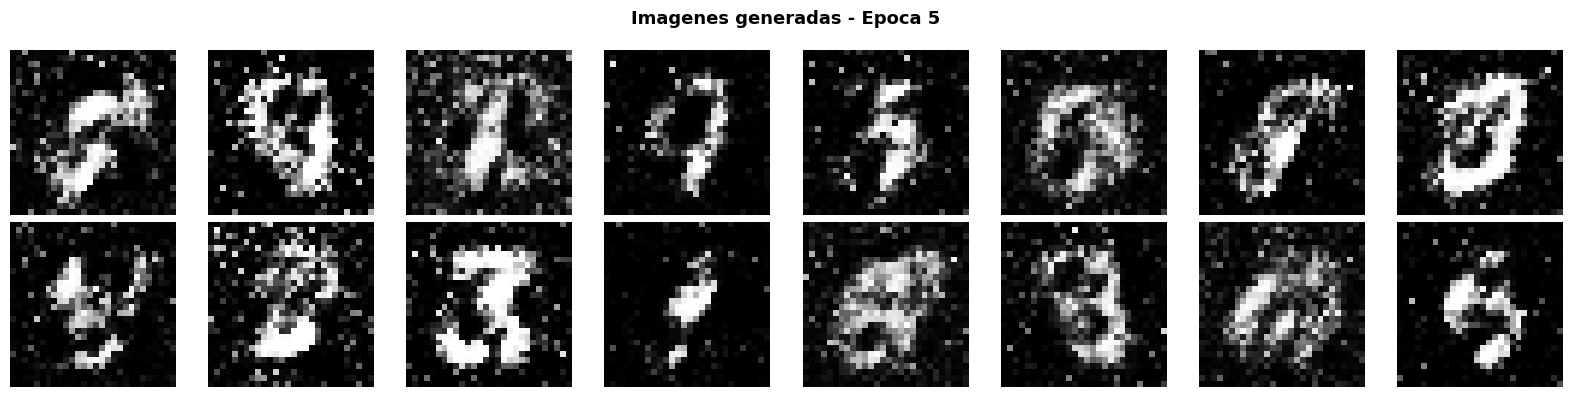

Epoca 06/30 | D-Loss: 0.5134 | G-Loss: 1.3301
Epoca 07/30 | D-Loss: 0.5103 | G-Loss: 1.3529
Epoca 08/30 | D-Loss: 0.5118 | G-Loss: 1.3564
Epoca 09/30 | D-Loss: 0.5145 | G-Loss: 1.3526
Epoca 10/30 | D-Loss: 0.5178 | G-Loss: 1.3456


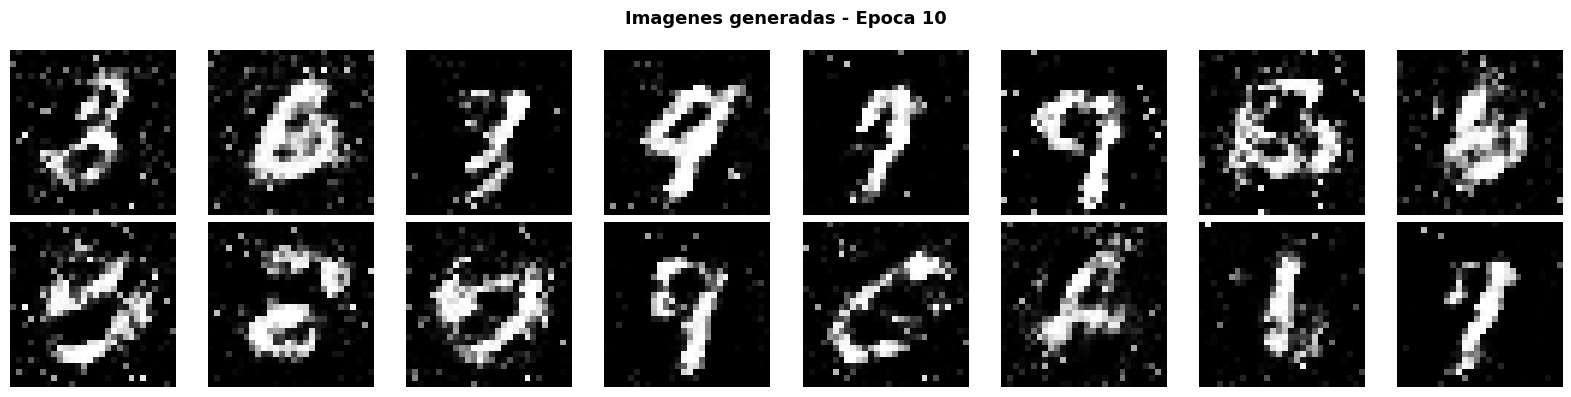

Epoca 11/30 | D-Loss: 0.5220 | G-Loss: 1.3351
Epoca 12/30 | D-Loss: 0.5265 | G-Loss: 1.3227
Epoca 13/30 | D-Loss: 0.5308 | G-Loss: 1.3100
Epoca 14/30 | D-Loss: 0.5350 | G-Loss: 1.2969
Epoca 15/30 | D-Loss: 0.5387 | G-Loss: 1.2849


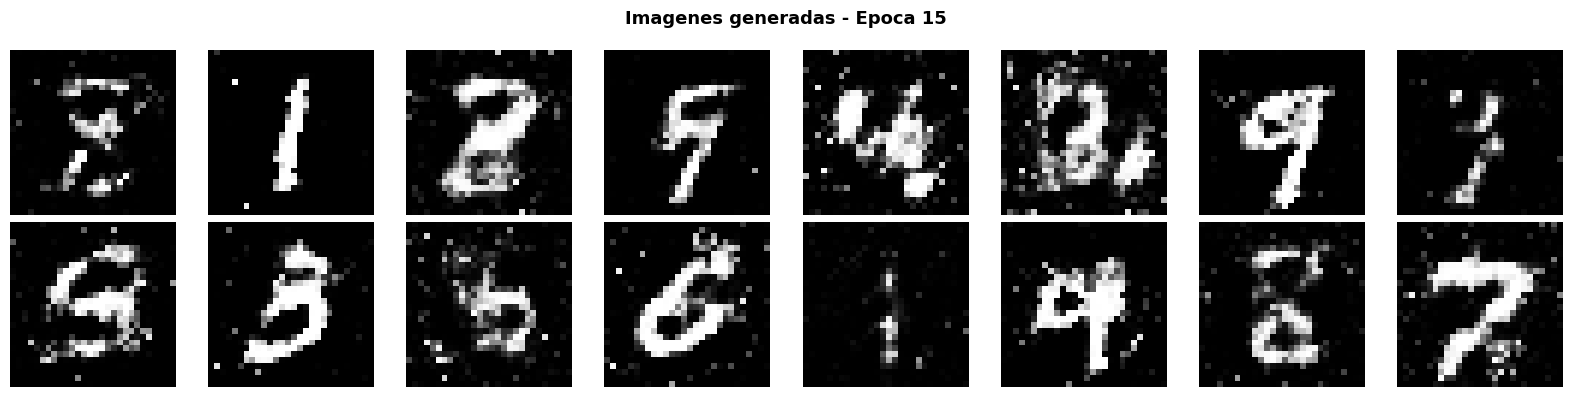

Epoca 16/30 | D-Loss: 0.5422 | G-Loss: 1.2736
Epoca 17/30 | D-Loss: 0.5454 | G-Loss: 1.2629
Epoca 18/30 | D-Loss: 0.5485 | G-Loss: 1.2529
Epoca 19/30 | D-Loss: 0.5514 | G-Loss: 1.2430
Epoca 20/30 | D-Loss: 0.5541 | G-Loss: 1.2340


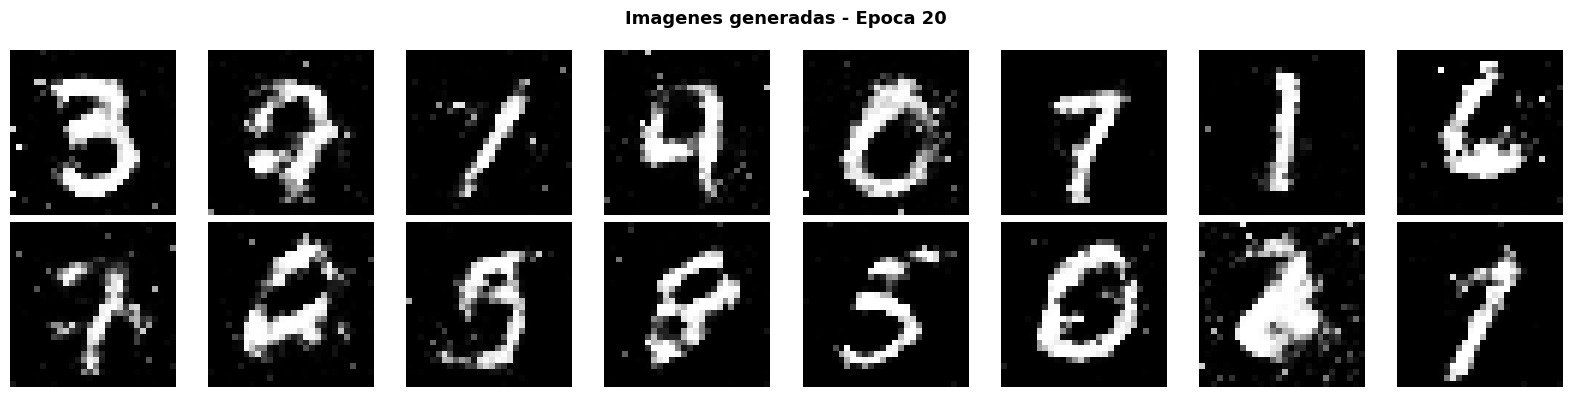

Epoca 21/30 | D-Loss: 0.5566 | G-Loss: 1.2256
Epoca 22/30 | D-Loss: 0.5590 | G-Loss: 1.2177
Epoca 23/30 | D-Loss: 0.5612 | G-Loss: 1.2102
Epoca 24/30 | D-Loss: 0.5633 | G-Loss: 1.2033
Epoca 25/30 | D-Loss: 0.5652 | G-Loss: 1.1966


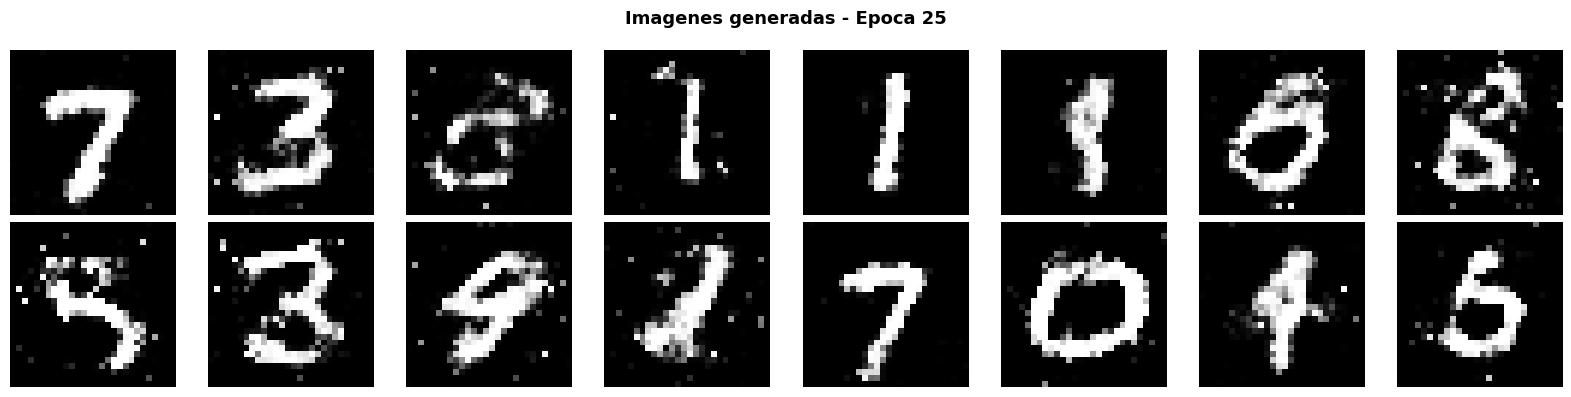

Epoca 26/30 | D-Loss: 0.5671 | G-Loss: 1.1904
Epoca 27/30 | D-Loss: 0.5688 | G-Loss: 1.1844
Epoca 28/30 | D-Loss: 0.5704 | G-Loss: 1.1788
Epoca 29/30 | D-Loss: 0.5719 | G-Loss: 1.1737
Epoca 30/30 | D-Loss: 0.5732 | G-Loss: 1.1689


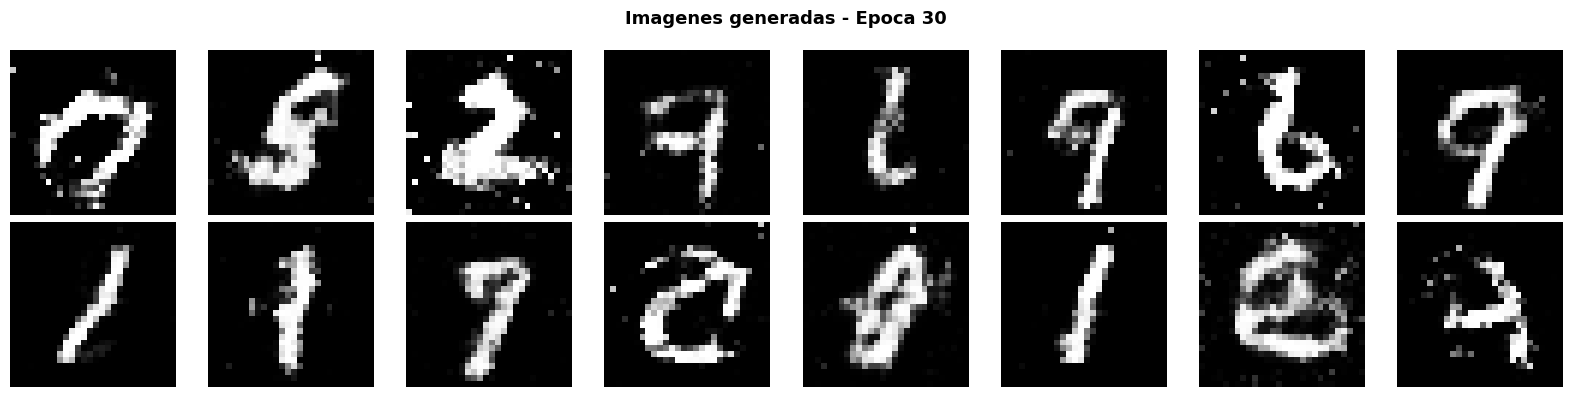

Entrenamiento finalizado


In [ ]:
EPOCHS = 30          # Numero de epocas de entrenamiento (limitado por hardware de Colab)
BATCH_SIZE = 128     # Tamano del mini-batch: balance entre estabilidad y velocidad
SAMPLE_INTERVAL = 5  # Cada cuantas epocas guardar imagenes de muestra para analisis

d_losses, g_losses = [], []

print(f'Iniciando entrenamiento: {EPOCHS} epocas | batch={BATCH_SIZE}')
print('=' * 55)

for epoch in range(1, EPOCHS + 1):

    epoch_d_loss = []
    epoch_g_loss = []
    n_batches = x_all.shape[0] // BATCH_SIZE

    for _ in range(n_batches):

        # PASO A: ENTRENAR EL DISCRIMINADOR

        # 1) Seleccionar un mini-batch de imagenes REALES aleatoriamente
        idx = np.random.randint(0, x_all.shape[0], BATCH_SIZE)
        real_images = x_all[idx]                               # shape: (128, 784)

        # 2) Generar imagenes FALSAS: muestrear ruido aleatorio del espacio latente
        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
        # normal(media=0, desv=1): distribucion gaussiana estandar
        fake_images = generator.predict(noise, verbose=0)     # shape: (128, 784)

        # 3) Crear etiquetas: 1 para reales, 0 para falsas
        real_labels = np.ones((BATCH_SIZE, 1))
        fake_labels = np.zeros((BATCH_SIZE, 1))

        # 4) Habilitar el entrenamiento del discriminador
        discriminator.trainable = True

        # 5) Entrenar el discriminador con imagenes reales y luego con falsas
        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

        # d_loss[0] = valor de perdida | d_loss[1] = accuracy
        d_loss_avg = 0.5 * (d_loss_real[0] + d_loss_fake[0])
        epoch_d_loss.append(d_loss_avg)

        # PASO B: ENTRENAR EL GENERADOR

        # 1) Generar nuevo ruido (siempre ruido fresco para diversidad)
        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))

        # 2) Etiqueta ENGANOSA: queremos que el generador haga que
        # el discriminador diga 'real' (1) para sus imagenes falsas
        misleading_labels = np.ones((BATCH_SIZE, 1))

        # 3) Congelar el discriminador para que solo se actualice el generador
        discriminator.trainable = False

        # 4) Entrenar el modelo GAN combinado (solo actualizara pesos del generador)
        g_loss = gan.train_on_batch(noise, misleading_labels)
        epoch_g_loss.append(g_loss)

    # REGISTRO POR EPOCA
    d_loss_mean = np.mean(epoch_d_loss)
    g_loss_mean = np.mean(epoch_g_loss)
    d_losses.append(d_loss_mean)
    g_losses.append(g_loss_mean)

    print(f'Epoca {epoch:02d}/{EPOCHS} | D-Loss: {d_loss_mean:.4f} | G-Loss: {g_loss_mean:.4f}')

    # Cada SAMPLE_INTERVAL epocas, mostrar imagenes generadas para seguimiento visual
    if epoch % SAMPLE_INTERVAL == 0:
        noise_sample = np.random.normal(0, 1, (16, LATENT_DIM))
        gen_imgs = generator.predict(noise_sample, verbose=0)
        gen_imgs = 0.5 * gen_imgs + 0.5   # Desnormalizar de [-1,1] a [0,1]

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        fig.suptitle(f'Imagenes generadas - Epoca {epoch}', fontsize=13, fontweight='bold')
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(gen_imgs[i].reshape(28, 28), cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.show()

print('Entrenamiento finalizado')

## 7. Analisis de las Curvas de Perdida

Las curvas de perdida son el principal indicador del comportamiento del entrenamiento adversarial.

**Interpretacion esperada:**
- **D-Loss** deberia mantenerse cerca de `0.5-0.7`: si baja mucho, el discriminador aplasta al generador; si sube mucho, el generador lo engana completamente
- **G-Loss** deberia bajar gradualmente indicando que el generador mejora en 'enganar' al discriminador
- El equilibrio de Nash ideal es cuando ambas perdidas se estabilizan juntas

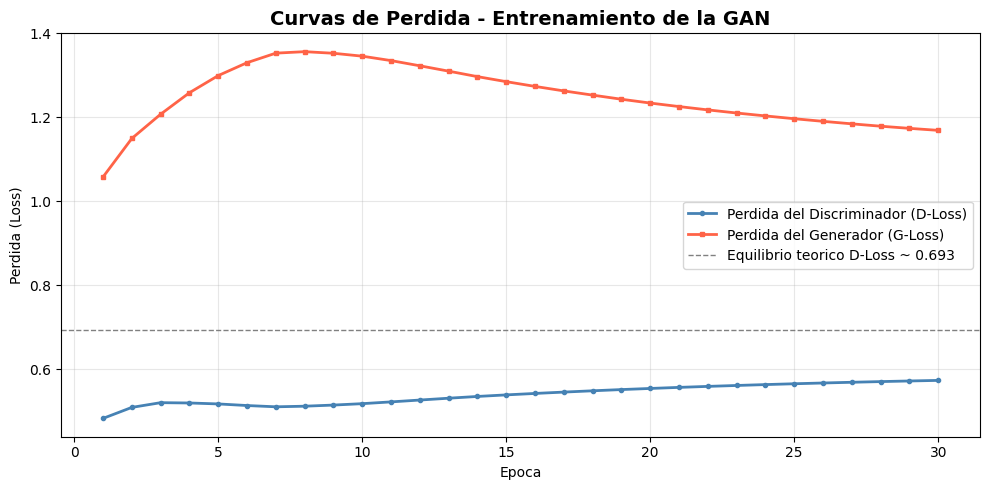

D-Loss final (epoca 30): 0.5732
G-Loss final (epoca 30): 1.1689


In [ ]:
epochs_range = list(range(1, EPOCHS + 1))

plt.figure(figsize=(10, 5))

# Curva del Discriminador
plt.plot(epochs_range, d_losses, label='Perdida del Discriminador (D-Loss)',
         color='steelblue', linewidth=2, marker='o', markersize=3)

# Curva del Generador
plt.plot(epochs_range, g_losses, label='Perdida del Generador (G-Loss)',
         color='tomato', linewidth=2, marker='s', markersize=3)

# Linea de referencia: perdida ideal del discriminador en equilibrio
# En equilibrio perfectamente equilibrado, D-Loss ~ ln(2) ~ 0.693
# porque el discriminador no puede distinguir reales de falsos (50/50)
plt.axhline(y=0.693, color='gray', linestyle='--', linewidth=1,
            label='Equilibrio teorico D-Loss ~ 0.693')

plt.title('Curvas de Perdida - Entrenamiento de la GAN', fontsize=14, fontweight='bold')
plt.xlabel('Epoca')
plt.ylabel('Perdida (Loss)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'D-Loss final (epoca {EPOCHS}): {d_losses[-1]:.4f}')
print(f'G-Loss final (epoca {EPOCHS}): {g_losses[-1]:.4f}')

## 8. Visualizacion de Imagenes Generadas vs. Reales

Comparar visualmente las imagenes generadas con imagenes reales del dataset  
permite evaluar cualitativamente la calidad del generador.

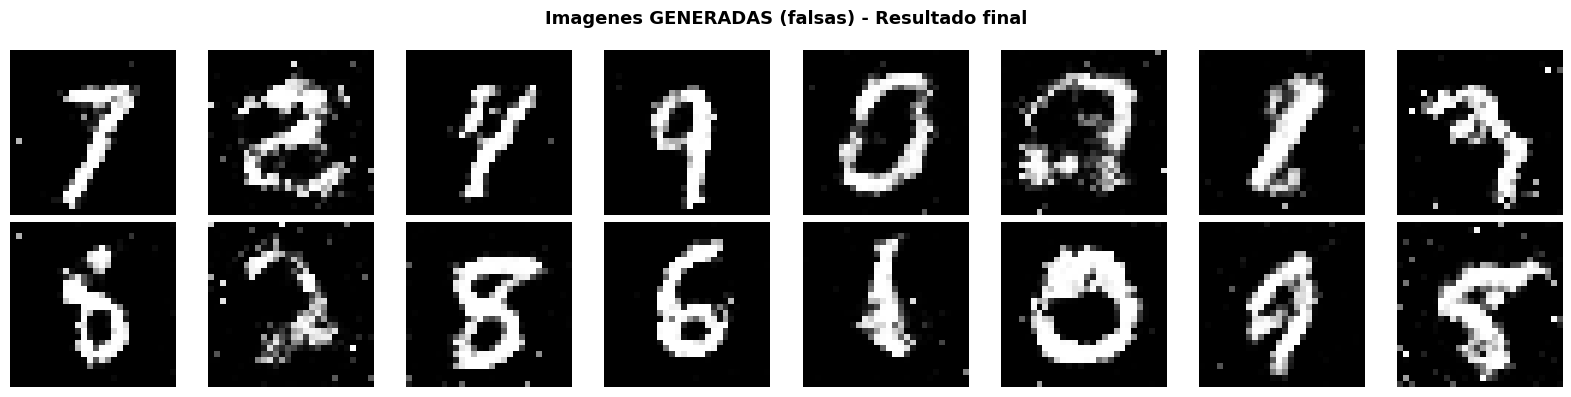

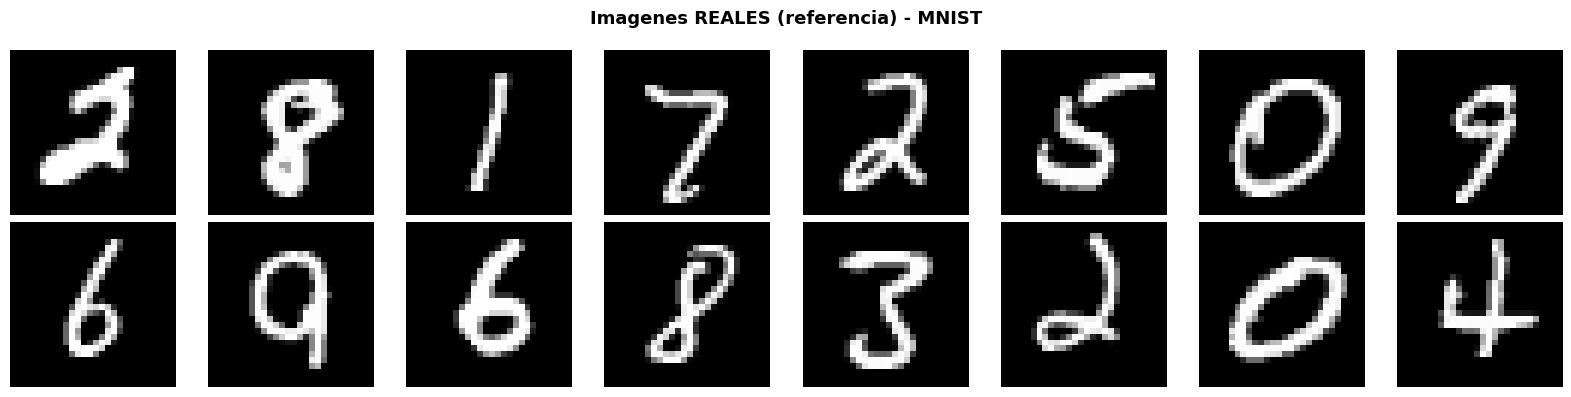

In [ ]:
# IMAGENES GENERADAS
noise_final = np.random.normal(0, 1, (16, LATENT_DIM))
final_images = generator.predict(noise_final, verbose=0)
# Desnormalizar: el generador produce valores en [-1, 1]
# matplotlib espera [0, 1] para escala de grises correcta
final_images = 0.5 * final_images + 0.5

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Imagenes GENERADAS (falsas) - Resultado final', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(final_images[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# IMAGENES REALES
real_sample_idx = np.random.randint(0, x_all.shape[0], 16)
real_sample = x_all[real_sample_idx]
real_sample_vis = 0.5 * real_sample + 0.5   # [-1,1] -> [0,1]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Imagenes REALES (referencia) - MNIST', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(real_sample_vis[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Analisis de Resultados y Conclusiones

In [ ]:
print('=' * 60)
print('ANALISIS CUANTITATIVO DEL ENTRENAMIENTO')
print('=' * 60)

diffs = [abs(d - g) for d, g in zip(d_losses, g_losses)]
best_epoch = diffs.index(min(diffs)) + 1

print(f'Perdidas finales:')
print(f'  D-Loss (epoca {EPOCHS}): {d_losses[-1]:.4f}')
print(f'  G-Loss (epoca {EPOCHS}): {g_losses[-1]:.4f}')
print(f'Equilibrio adversarial:')
print(f'  Epoca con menor |D-Loss - G-Loss|: {best_epoch}')
print(f'  Diferencia minima: {min(diffs):.4f}')
print(f'Evolucion del Generador:')
print(f'  G-Loss inicial (epoca 1): {g_losses[0]:.4f}')
print(f'  G-Loss final   (epoca {EPOCHS}): {g_losses[-1]:.4f}')
mejora = g_losses[0] - g_losses[-1]
print(f'  Reduccion de perdida: {mejora:.4f}')

print()
print('CONCLUSIONES')
print('=' * 60)
conclusiones = """
1. ARQUITECTURA:
   El generador transforma vectores de ruido (100 dims) en imagenes
   de 784 pixeles mediante capas densas con LeakyReLU. La activacion
   tanh en la salida garantiza coherencia con la normalizacion [-1,1].
   El discriminador usa Dropout para evitar sobreajuste y no dominar
   al generador desde el inicio del entrenamiento.

2. DINAMICA ADVERSARIAL:
   La interaccion G vs. D sigue el juego minimax de la teoria de GANs.
   El equilibrio de Nash teorico ocurre cuando D-Loss ~ 0.693 (ln 2),
   punto donde D no puede distinguir reales de falsos mejor que el azar.

3. CALIDAD DE LAS IMAGENES:
   Con 30 epocas y arquitectura densa, las imagenes generadas muestran
   la estructura general de digitos pero con menor nitidez que MNIST
   real. Esto es esperable dado el hardware limitado de Colab y la
   ausencia de capas convolucionales.

4. LIMITACIONES Y MEJORAS POSIBLES:
   - Mas epocas (100+) mejorarian la calidad visual notablemente
   - Una arquitectura convolucional (DCGAN) capturaria mejor la
     estructura espacial de los digitos
   - Batch Normalization estabilizaria mas el entrenamiento adversarial

5. COMPRENSION DEL FLUJO TECNICO:
   La actividad demostro que el entrenamiento adversarial funciona
   alternando las actualizaciones de G y D, controlando que parametros
   son entrenables en cada paso para mantener senales de gradiente
   coherentes en ambos modelos.
"""
print(conclusiones)

ANALISIS CUANTITATIVO DEL ENTRENAMIENTO
Perdidas finales:
  D-Loss (epoca 30): 0.5732
  G-Loss (epoca 30): 1.1689
Equilibrio adversarial:
  Epoca con menor |D-Loss - G-Loss|: 1
  Diferencia minima: 0.5751
Evolucion del Generador:
  G-Loss inicial (epoca 1): 1.0579
  G-Loss final   (epoca 30): 1.1689
  Reduccion de perdida: -0.1111

CONCLUSIONES

1. ARQUITECTURA:
   El generador transforma vectores de ruido (100 dims) en imagenes
   de 784 pixeles mediante capas densas con LeakyReLU. La activacion
   tanh en la salida garantiza coherencia con la normalizacion [-1,1].
   El discriminador usa Dropout para evitar sobreajuste y no dominar
   al generador desde el inicio del entrenamiento.

2. DINAMICA ADVERSARIAL:
   La interaccion G vs. D sigue el juego minimax de la teoria de GANs.
   El equilibrio de Nash teorico ocurre cuando D-Loss ~ 0.693 (ln 2),
   punto donde D no puede distinguir reales de falsos mejor que el azar.

3. CALIDAD DE LAS IMAGENES:
   Con 30 epocas y arquitectura densa,

---
## 10. Resumen Final

**Actividad realizada en Google Colab con TensorFlow/Keras }**

| Aspecto | Detalles |
|---|---|
| **Dataset** | MNIST (70 000 imagenes, 28x28) |
| **Arquitectura Generador** | Dense(256) -> Dense(512) -> Dense(784, tanh) |
| **Arquitectura Discriminador** | Dense(512)+Dropout -> Dense(256)+Dropout -> Dense(1, sigmoid) |
| **Optimizador** | Adam (lr=0.0002, beta1=0.5) |
| **Epocas** | 30 |
| **Batch Size** | 128 |
| **Espacio Latente** | 100 dimensiones |